# Streamlined Microarray Analysis Pipeline
**Drop your files in the same folder as this notebook:**
- `GSEXXXX_series_matrix.txt.gz`
- `GSEXXXX.top.table.tsv`
- `tableDEG.csv`

Then run all cells. Everything is automatic.

In [3]:
# ============================================================
# CELL 1: IMPORTS & FILE DISCOVERY
# ============================================================
import os, gzip, shutil, csv
import pandas as pd
import numpy as np
from sklearn.preprocessing import quantile_transform

print('='*60)
print('STEP 0: SCANNING DIRECTORY FOR INPUT FILES')
print('='*60)

# current_directory = os.getcwd()
current_directory = 'data/gse33630'
folder_name = os.path.basename(current_directory)
print(f'[INFO] Working directory : {current_directory}')
print(f'[INFO] Folder name (prefix): {folder_name}')
print(f'[INFO] All files found:')
for f in sorted(os.listdir(current_directory)):
    print(f'         {f}')

# --- Auto-detect required files ---
input_tsv, input_gz, table_deg = None, None, None

for f in os.listdir(current_directory):
    if f.endswith('.top.table.tsv'):
        input_tsv = f
        print(f'[FOUND] TSV file  -> {f}')
    elif f.endswith('_series_matrix.txt.gz'):
        input_gz = f
        print(f'[FOUND] GZ file   -> {f}')
    elif f == 'tableDEG.csv':
        table_deg = f
        print(f'[FOUND] tableDEG  -> {f}')

# --- Hard stop if anything is missing ---
missing = []
if not input_tsv:  missing.append('GSEXXXX.top.table.tsv')
if not input_gz:   missing.append('GSEXXXX_series_matrix.txt.gz')
if not table_deg:  missing.append('tableDEG.csv')

if missing:
    raise FileNotFoundError(
        f'[FATAL] Missing required input file(s): {", ".join(missing)}\n'
        f'        Place them in: {current_directory}'
    )

# Derive output file names from the GSE ID in the .gz filename
# e.g. GSE37250_series_matrix.txt.gz -> GSE37250
gse_id = input_gz.replace('_series_matrix.txt.gz', '')
print(f'[INFO] Detected GSE ID: {gse_id}')

output_csv             = input_tsv.replace('.top.table.tsv', '.csv')
gz_to_txt              = f'{gse_id}_series_matrixpre_mod.txt'
series_matrix_txt      = f'{gse_id}_series_matrix.txt'
log_norm_file          = f'{gse_id}_log_quantile_normalized_data.csv'
totalDEG_file          = f'{folder_name}_totalDEG.csv'
merged_no_class_file   = f'{folder_name}_merged_file_no_class.csv'
merged_transposed_pre  = f'{folder_name}_merged_transposed_pre.csv'
merged_transposed_file = f'{folder_name}_merged_transposed.csv'
merged_modified_file   = f'{folder_name}_merged_modified.csv'
merged_class_file      = f'{folder_name}_merged_transposed_class_added.csv'
selected_features_file = f'{folder_name}_selected_features_with_class.csv'
svm_rfe_file           = f'{folder_name}_svm_rfe_selected_features.csv'

print('\n[OK] File discovery complete. Ready to run pipeline.')


STEP 0: SCANNING DIRECTORY FOR INPUT FILES
[INFO] Working directory : data/gse33630
[INFO] Folder name (prefix): gse33630
[INFO] All files found:
         GSE33630.top.table.tsv
         GSE33630_series_matrix.txt.gz
         README.txt
         backup
         gse33630_tableDEG.csv
         tableDEG.csv
[FOUND] TSV file  -> GSE33630.top.table.tsv
[FOUND] GZ file   -> GSE33630_series_matrix.txt.gz
[FOUND] tableDEG  -> tableDEG.csv
[INFO] Detected GSE ID: GSE33630

[OK] File discovery complete. Ready to run pipeline.


In [11]:
# ============================================================
# CELL 2: TSV -> CSV  +  GZ EXTRACTION  +  SERIES MATRIX CLEAN
# ============================================================
print('='*60)
print('STEP 1: FILE CONVERSION')
print('='*60)

# --- TSV -> CSV ---
print(f'[INFO] Converting {input_tsv} -> {output_csv} ...')
try:
    with open(input_tsv, 'r', newline='', encoding='utf-8') as tsv_f, \
         open(output_csv, 'w', newline='', encoding='utf-8') as csv_f:
        writer = csv.writer(csv_f)
        for row in csv.reader(tsv_f, delimiter='\t'):
            writer.writerow(row)
    print(f'[OK] TSV -> CSV done. Output: {output_csv}')
except Exception as e:
    raise RuntimeError(f'[FATAL] TSV->CSV conversion failed: {e}')

# --- Quick sanity check on the CSV ---
try:
    _check = pd.read_csv(output_csv, nrows=3)
    print(f'[DEBUG] CSV preview (3 rows):\n{_check.head(3)}')
    required_cols = ['ID', 'logFC', 'adj.P.Val', 'Gene.symbol']
    missing_cols = [c for c in required_cols if c not in _check.columns]
    if missing_cols:
        raise ValueError(
            f'[FATAL] CSV is missing expected columns: {missing_cols}\n'
            f'        Actual columns found: {list(_check.columns)}'
        )
    print(f'[OK] Required columns present: {required_cols}')
except Exception as e:
    raise RuntimeError(f'[FATAL] CSV validation failed: {e}')

# --- GZ extraction ---
print(f'\n[INFO] Extracting {input_gz} -> {gz_to_txt} ...')
try:
    with gzip.open(input_gz, 'rb') as gz_f, open(gz_to_txt, 'wb') as out_f:
        shutil.copyfileobj(gz_f, out_f)
    size_kb = os.path.getsize(gz_to_txt) // 1024
    print(f'[OK] Extracted. Size: {size_kb} KB')
except Exception as e:
    raise RuntimeError(f'[FATAL] GZ extraction failed: {e}')

# --- Clean series matrix: remove lines starting with '!' ---
print(f'[INFO] Cleaning series matrix -> {series_matrix_txt} ...')
lines_written = 0
lines_skipped = 0
try:
    with open(gz_to_txt, 'r', encoding='utf-8', errors='replace') as rf, \
         open(series_matrix_txt, 'w') as wf:
        for line in rf:
            if line.startswith('!') or not line.strip():
                lines_skipped += 1
            else:
                wf.write(line)
                lines_written += 1
    print(f'[OK] Series matrix cleaned. Lines written: {lines_written}, skipped: {lines_skipped}')
except Exception as e:
    raise RuntimeError(f'[FATAL] Series matrix cleaning failed: {e}')

# --- Peek at the cleaned file to verify structure ---
print('[DEBUG] First 3 lines of cleaned series matrix:')
with open(series_matrix_txt, 'r') as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f'  Line {i}: {line[:120].rstrip()}')


STEP 1: FILE CONVERSION
[INFO] Converting GSE33630.top.table.tsv -> GSE33630.csv ...
[OK] TSV -> CSV done. Output: GSE33630.csv
[DEBUG] CSV preview (3 rows):
          ID     adj.P.Val       P.Value          t          B     logFC  \
0  205612_at  9.750000e-37  1.780000e-41 -22.146272  83.540928 -4.205287   
1  214044_at  4.270000e-30  1.560000e-34 -18.304316  67.936561 -2.448740   
2  242496_at  2.450000e-29  1.340000e-33 -17.818482  65.826831 -1.943923   

  Gene.symbol                                       Gene.title  
0       MMRN1                                     multimerin 1  
1        RYR2                             ryanodine receptor 2  
2        ART4  ADP-ribosyltransferase 4 (Dombrock blood group)  
[OK] Required columns present: ['ID', 'logFC', 'adj.P.Val', 'Gene.symbol']

[INFO] Extracting GSE33630_series_matrix.txt.gz -> GSE33630_series_matrixpre_mod.txt ...
[OK] Extracted. Size: 67439 KB
[INFO] Cleaning series matrix -> GSE33630_series_matrix.txt ...
[OK] Series matri

In [12]:
# ============================================================
# CELL 3: totalDEG FILTERING  (adj.P.Val <= 0.05  +  |logFC| >= 1)
# ============================================================
print('='*60)
print('STEP 2: totalDEG FILTERING')
print('='*60)

df = pd.read_csv(output_csv)
print(f'[INFO] Loaded {output_csv}: {df.shape[0]} rows, {df.shape[1]} cols')
print(f'[DEBUG] Columns: {list(df.columns)}')

# -- adj.P.Val filter --
before = len(df)
df_filtered = df[df['adj.P.Val'] <= 0.05]
print(f'[FILTER] adj.P.Val <= 0.05 : {before} -> {len(df_filtered)} rows  (removed {before - len(df_filtered)})')

# -- |logFC| >= 1 filter --
# BUG FIX: original code used >= 1 OR <= -1 which is CORRECT,
# BUT if logFC column has been stored as string or has NaN, the filter silently drops rows.
# We force numeric and report NaN count BEFORE filtering.
df_filtered = df_filtered.copy()
non_numeric_logfc = df_filtered['logFC'].apply(lambda x: not pd.api.types.is_number(x)).sum()
if non_numeric_logfc > 0:
    print(f'[WARNING] {non_numeric_logfc} non-numeric values in logFC column – they will be dropped')

df_filtered['logFC'] = pd.to_numeric(df_filtered['logFC'], errors='coerce')
nan_logfc = df_filtered['logFC'].isna().sum()
if nan_logfc > 0:
    print(f'[WARNING] {nan_logfc} NaN values in logFC after coercion – dropping them')
    df_filtered = df_filtered.dropna(subset=['logFC'])

before = len(df_filtered)
# KEY FIX: use abs() to make the intent unambiguous and debug the distribution
logfc_abs = df_filtered['logFC'].abs()
print(f'[DEBUG] logFC absolute value distribution before filter:')
print(f'        min={logfc_abs.min():.4f}  max={logfc_abs.max():.4f}  '
      f'median={logfc_abs.median():.4f}')
print(f'        Rows with |logFC| < 1 (will be removed): {(logfc_abs < 1).sum()}')
print(f'        Rows with |logFC| >= 1 (will be kept)  : {(logfc_abs >= 1).sum()}')

df_filtered = df_filtered[logfc_abs >= 1]
print(f'[FILTER] |logFC| >= 1 : {before} -> {len(df_filtered)} rows  (removed {before - len(df_filtered)})')

if len(df_filtered) == 0:
    raise ValueError(
        '[FATAL] Zero rows remaining after logFC filter!\n'
        '        Possible causes:\n'
        '        1. logFC column contains already-absolute values (all positive, threshold issue)\n'
        '        2. Wrong column name – check the CSV header for the actual FC column name\n'
        f'       Columns available: {list(df.columns)}\n'
        f'       logFC sample values: {df["logFC"].head(10).tolist()}'
    )

if len(df_filtered) <= 10:
    print(f'[WARNING] Only {len(df_filtered)} rows after filtering – this seems low. '
          'Check thresholds or input data.')

# -- Drop rows without Gene.symbol --
before = len(df_filtered)
df_filtered = df_filtered.dropna(subset=['Gene.symbol'])
print(f'[FILTER] Drop NaN Gene.symbol : {before} -> {len(df_filtered)} rows')

# -- Keep best probe per gene --
before = len(df_filtered)
df_filtered = df_filtered.loc[df_filtered.groupby('Gene.symbol')['adj.P.Val'].idxmin()]
print(f'[FILTER] Best probe per gene  : {before} -> {len(df_filtered)} rows')

df_filtered.to_csv(totalDEG_file, index=False)
print(f'[OK] totalDEG saved to {totalDEG_file}  ({len(df_filtered)} genes)')


STEP 2: totalDEG FILTERING
[INFO] Loaded GSE33630.csv: 54675 rows, 8 cols
[DEBUG] Columns: ['ID', 'adj.P.Val', 'P.Value', 't', 'B', 'logFC', 'Gene.symbol', 'Gene.title']
[FILTER] adj.P.Val <= 0.05 : 54675 -> 25161 rows  (removed 29514)
[DEBUG] logFC absolute value distribution before filter:
        min=0.0485  max=5.2642  median=0.3563
        Rows with |logFC| < 1 (will be removed): 22944
        Rows with |logFC| >= 1 (will be kept)  : 2217
[FILTER] |logFC| >= 1 : 25161 -> 2217 rows  (removed 22944)
[FILTER] Drop NaN Gene.symbol : 2217 -> 2088 rows
[FILTER] Best probe per gene  : 2088 -> 1473 rows
[OK] totalDEG saved to gse3360_totalDEG.csv  (1473 genes)


In [13]:
# ============================================================
# CELL 4: LOG2 QUANTILE NORMALIZATION OF SERIES MATRIX
# ============================================================
print('='*60)
print('STEP 3: LOG2 QUANTILE NORMALIZATION')
print('='*60)

print(f'[INFO] Reading series matrix: {series_matrix_txt}')
try:
    microarray_data = pd.read_csv(series_matrix_txt, sep='\t')
    print(f'[INFO] Raw shape: {microarray_data.shape}')
    print(f'[DEBUG] First 3 columns: {list(microarray_data.columns[:3])}')
except Exception as e:
    raise RuntimeError(f'[FATAL] Could not read series matrix: {e}')

if 'ID_REF' not in microarray_data.columns:
    raise ValueError(
        f'[FATAL] ID_REF column not found.\n'
        f'        Columns present: {list(microarray_data.columns[:10])}\n'
        f'        Check that the series matrix was cleaned correctly (Cell 2).'
    )

microarray_data.set_index('ID_REF', inplace=True)
print(f'[INFO] After setting ID_REF as index: {microarray_data.shape[0]} probes x {microarray_data.shape[1]} samples')

# --- Convert all to numeric, report failures ---
non_num_cols = [c for c in microarray_data.columns
                if not pd.api.types.is_numeric_dtype(microarray_data[c])]
if non_num_cols:
    print(f'[WARNING] {len(non_num_cols)} non-numeric columns – coercing: {non_num_cols[:5]}')
    microarray_data = microarray_data.apply(pd.to_numeric, errors='coerce')

nan_before = microarray_data.isna().sum().sum()
if nan_before > 0:
    print(f'[WARNING] {nan_before} NaN values in expression matrix – filling with column median')
    microarray_data = microarray_data.fillna(microarray_data.median())

# --- Non-positive values ---
n_nonpos = (microarray_data <= 0).sum().sum()
if n_nonpos > 0:
    print(f'[WARNING] {n_nonpos} non-positive values – adding 1e-5 before log2')
    microarray_data += 1e-5

log2_data = np.log2(microarray_data)
nan_after_log = log2_data.isna().sum().sum()
if nan_after_log > 0:
    print(f'[WARNING] {nan_after_log} NaN values after log2 transform – check for negative/zero values')

n_quantiles = min(50, log2_data.shape[0])
print(f'[INFO] Running quantile normalization (n_quantiles={n_quantiles}) ...')
qn = quantile_transform(log2_data, n_quantiles=n_quantiles, axis=0, random_state=0, copy=True)
qn_df = pd.DataFrame(qn, columns=microarray_data.columns, index=microarray_data.index)
qn_df.to_csv(log_norm_file)
print(f'[OK] Normalized data saved to {log_norm_file}  shape={qn_df.shape}')


STEP 3: LOG2 QUANTILE NORMALIZATION
[INFO] Reading series matrix: GSE33630_series_matrix.txt
[INFO] Raw shape: (54675, 106)
[DEBUG] First 3 columns: ['ID_REF', 'GSM831749', 'GSM831750']
[INFO] After setting ID_REF as index: 54675 probes x 105 samples
[INFO] Running quantile normalization (n_quantiles=50) ...
[OK] Normalized data saved to GSE33630_log_quantile_normalized_data.csv  shape=(54675, 105)


In [14]:
# ============================================================
# CELL 5: MERGE totalDEG + NORMALIZED MATRIX
# ============================================================
print('='*60)
print('STEP 4: MERGE totalDEG + NORMALIZED MATRIX')
print('='*60)

df1 = pd.read_csv(totalDEG_file)
df2 = pd.read_csv(log_norm_file)
print(f'[INFO] totalDEG shape       : {df1.shape}')
print(f'[INFO] Normalized mat shape : {df2.shape}')
print(f'[DEBUG] totalDEG columns    : {list(df1.columns[:6])}')
print(f'[DEBUG] Norm mat columns    : {list(df2.columns[:6])}')

if 'ID' not in df1.columns:
    raise ValueError(f'[FATAL] "ID" column missing from totalDEG. Columns: {list(df1.columns)}')
if 'ID_REF' not in df2.columns:
    raise ValueError(f'[FATAL] "ID_REF" column missing from normalized matrix. Columns: {list(df2.columns[:10])}')

overlap = set(df1['ID'].astype(str)) & set(df2['ID_REF'].astype(str))
print(f'[DEBUG] ID overlap between totalDEG and normalized matrix: {len(overlap)} probes')
if len(overlap) == 0:
    raise ValueError(
        '[FATAL] No matching IDs between totalDEG and normalized matrix!\n'
        f'        totalDEG ID sample   : {df1["ID"].head(5).tolist()}\n'
        f'        Norm mat ID_REF sample: {df2["ID_REF"].head(5).tolist()}'
    )

drop_cols = [c for c in ['adj.P.Val', 'P.Value', 't', 'B', 'logFC', 'Gene.title', 'ID_REF']
             if c in {**dict.fromkeys(df1.columns), **dict.fromkeys(df2.columns)}]
merged_df = pd.merge(df1, df2, left_on='ID', right_on='ID_REF').drop(columns=['ID'])
cols_to_drop = [c for c in ['adj.P.Val', 'P.Value', 't', 'B', 'logFC', 'Gene.title', 'ID_REF']
                if c in merged_df.columns]
merged_df = merged_df.drop(columns=cols_to_drop)

print(f'[INFO] Merged shape (before class): {merged_df.shape}')
merged_df.to_csv(merged_no_class_file, index=False)
print(f'[OK] Saved {merged_no_class_file}')


STEP 4: MERGE totalDEG + NORMALIZED MATRIX
[INFO] totalDEG shape       : (1473, 8)
[INFO] Normalized mat shape : (54675, 106)
[DEBUG] totalDEG columns    : ['ID', 'adj.P.Val', 'P.Value', 't', 'B', 'logFC']
[DEBUG] Norm mat columns    : ['ID_REF', 'GSM831749', 'GSM831750', 'GSM831751', 'GSM831752', 'GSM831753']
[DEBUG] ID overlap between totalDEG and normalized matrix: 1473 probes
[INFO] Merged shape (before class): (1473, 106)
[OK] Saved gse3360_merged_file_no_class.csv


In [15]:
# ============================================================
# CELL 6: TRANSPOSE  (with AUTOMATIC row-skip detection)
# ============================================================
print('='*60)
print('STEP 5: TRANSPOSE')
print('='*60)

merged_transposed = merged_df.reset_index(drop=True).T
merged_transposed.to_csv(merged_transposed_pre)
print(f'[INFO] Pre-transpose saved: {merged_transposed_pre}  shape={merged_transposed.shape}')

# AUTO-DETECT where the Gene.symbol header row is.
# The raw transposed CSV looks like:
#   row 0: blank index row  (from pandas .T saving the numeric index as first col)
#   row 1: possibly a GI / extra annotation row
#   row N: Gene.symbol row  <- THIS is the actual header we want
print('[DEBUG] Scanning for Gene.symbol header row in transposed CSV...')
gene_symbol_row_idx = None
with open(merged_transposed_pre, 'r') as f:
    for i, line in enumerate(f):
        print(f'  Row {i}: {line[:120].rstrip()}')
        if 'Gene.symbol' in line:
            gene_symbol_row_idx = i
            print(f'[FOUND] Gene.symbol is at row index {i} – will skip rows 0..{i}')
            break
        if i > 10:  # Safety: only scan first 10 rows
            break

if gene_symbol_row_idx is None:
    raise ValueError(
        '[FATAL] Could not find "Gene.symbol" in the transposed CSV header rows.\n'
        '        Check that the merged DataFrame has a Gene.symbol column.'
    )

# Write the final transposed file, skipping rows before Gene.symbol
rows_written = 0
with open(merged_transposed_pre, 'r') as infile, \
     open(merged_transposed_file, 'w', newline='') as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile)
    for i, row in enumerate(reader):
        if i < gene_symbol_row_idx:
            print(f'[SKIP] Row {i} (pre-header): {str(row[:4])}')
            continue
        writer.writerow(row)
        rows_written += 1

print(f'[OK] Transposed file written: {merged_transposed_file}  ({rows_written} rows)')

# Quick peek at the result
_t = pd.read_csv(merged_transposed_file, nrows=3)
print(f'[DEBUG] Transposed preview (3 rows):\n{_t.head(3)}')


STEP 5: TRANSPOSE
[INFO] Pre-transpose saved: gse3360_merged_transposed_pre.csv  shape=(106, 1473)
[DEBUG] Scanning for Gene.symbol header row in transposed CSV...
  Row 0: ,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,
  Row 1: Gene.symbol,AADACP1,AAK1,ABCA8,ABCC3,ABI3BP,ABLIM1,ABR,ACACB,ACADL,ACADSB,ACKR3,ACOT7,ACP5,ACSF2,ACSL5,ACTA2,ACTN1,ADAL,
[FOUND] Gene.symbol is at row index 1 – will skip rows 0..1
[SKIP] Row 0 (pre-header): ['', '0', '1', '2']
[OK] Transposed file written: gse3360_merged_transposed.csv  (106 rows)
[DEBUG] Transposed preview (3 rows):
  Gene.symbol   AADACP1      AAK1     ABCA8     ABCC3    ABI3BP    ABLIM1  \
0   GSM831749  0.100415  0.918615  0.121508  0.690702  0.878641  0.915435   
1   GSM831750  0.144177  0.932547  0.781487  0.946737  0.929582  0.961665   
2   GSM831751  0.123721  0.928506  0.683175  0.904228  0.961168  0.939140   

        ABR     ACACB     ACADL  ...    ZNF132    Z

In [16]:
# ============================================================
# CELL 7: ADD CLASS LABELS FROM tableDEG.csv
# ============================================================
print('='*60)
print('STEP 6: ADD CLASS LABELS')
print('='*60)

df_table = pd.read_csv(table_deg)
df_trans  = pd.read_csv(merged_transposed_file)

print(f'[INFO] tableDEG shape    : {df_table.shape}')
print(f'[DEBUG] tableDEG columns : {list(df_table.columns)}')
print(f'[DEBUG] tableDEG head:\n{df_table.head(3)}')
print(f'[INFO] Transposed shape  : {df_trans.shape}')
print(f'[DEBUG] Transposed columns (first 5): {list(df_trans.columns[:5])}')

if 'Accession' not in df_table.columns:
    raise ValueError(
        f'[FATAL] "Accession" column not found in tableDEG.csv.\n'
        f'        Columns present: {list(df_table.columns)}'
    )
if 'Gene.symbol' not in df_trans.columns:
    raise ValueError(
        f'[FATAL] "Gene.symbol" column not found in transposed file.\n'
        f'        Columns present: {list(df_trans.columns[:10])}\n'
        f'        This usually means the header-row detection in Cell 6 picked the wrong row.'
    )

overlap2 = set(df_trans['Gene.symbol'].astype(str)) & set(df_table['Accession'].astype(str))
print(f'[DEBUG] Gene.symbol / Accession overlap: {len(overlap2)} entries')
if len(overlap2) == 0:
    raise ValueError(
        '[FATAL] No matching Gene.symbol <-> Accession entries!\n'
        f'        Transposed Gene.symbol sample : {df_trans["Gene.symbol"].head(5).tolist()}\n'
        f'        tableDEG Accession sample     : {df_table["Accession"].head(5).tolist()}'
    )

merged_df2 = pd.merge(
    df_trans, df_table,
    left_on='Gene.symbol', right_on='Accession'
).drop(columns=['Accession', 'Gene.symbol'])

print(f'[INFO] After class merge shape: {merged_df2.shape}')

# --- Drop any lingering index/unnamed columns ---
unnamed = [c for c in merged_df2.columns if str(c).startswith('Unnamed')]
if unnamed:
    print(f'[INFO] Dropping unnamed columns: {unnamed}')
    merged_df2 = merged_df2.drop(columns=unnamed)

# Check CLASS column was added
if 'CLASS' not in merged_df2.columns:
    print(f'[WARNING] "CLASS" column not found after merge. Columns: {list(merged_df2.columns[-5:])}')

merged_df2.to_csv(merged_modified_file, index=False)
print(f'[OK] Saved with class labels: {merged_modified_file}')

# Save clean version too (same content, legacy name)
merged_df2.to_csv(merged_class_file, index=False)
print(f'[OK] Also saved as: {merged_class_file}')


STEP 6: ADD CLASS LABELS
[INFO] tableDEG shape    : (105, 2)
[DEBUG] tableDEG columns : ['Accession', 'CLASS']
[DEBUG] tableDEG head:
   Accession  CLASS
0  GSM831749      1
1  GSM831750      1
2  GSM831751      1
[INFO] Transposed shape  : (105, 1474)
[DEBUG] Transposed columns (first 5): ['Gene.symbol', 'AADACP1', 'AAK1', 'ABCA8', 'ABCC3']
[DEBUG] Gene.symbol / Accession overlap: 105 entries
[INFO] After class merge shape: (105, 1474)
[OK] Saved with class labels: gse3360_merged_modified.csv
[OK] Also saved as: gse3360_merged_transposed_class_added.csv


In [17]:
# ============================================================
# CELL 8: mRMR FEATURE SELECTION
# ============================================================
import math
from sklearn.feature_selection import mutual_info_classif

print('='*60)
print('STEP 7: mRMR FEATURE SELECTION')
print('='*60)

data = pd.read_csv(merged_modified_file)
print(f'[INFO] Loaded {merged_modified_file}: {data.shape}')

if 'CLASS' not in data.columns:
    raise ValueError(
        f'[FATAL] "CLASS" column not found in {merged_modified_file}.\n'
        f'        Available columns (last 5): {list(data.columns[-5:])}'
    )

featnum = math.ceil((len(data.columns) - 1) * 0.8)  # exclude CLASS col
print(f'[INFO] Total features (excl CLASS): {len(data.columns)-1}')
print(f'[INFO] Selecting top {featnum} features (80%)')

data.iloc[:, :-1] = data.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')
nan_count = data.iloc[:, :-1].isna().sum().sum()
if nan_count > 0:
    print(f'[WARNING] {nan_count} NaN values in features – filling with column mean')
    data.iloc[:, :-1] = data.iloc[:, :-1].fillna(data.iloc[:, :-1].mean())

data['CLASS'] = data['CLASS'].astype('category').cat.codes
print(f'[DEBUG] CLASS distribution:\n{data["CLASS"].value_counts().to_dict()}')

X = data.iloc[:, :-1]
y = data['CLASS']

print('[INFO] Computing mutual information scores...')
mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({'Feature': X.columns, 'Score': mi_scores}).sort_values('Score', ascending=False)

top_features = mi_df.head(featnum)['Feature'].tolist()
selected_data = data[top_features + ['CLASS']]
selected_data.to_csv(selected_features_file, index=False)

mi_df.head(featnum).to_csv(f'{folder_name}_selected_{featnum}_features_with_scores.csv', index=False)

print(f'[OK] Selected {featnum} features saved to {selected_features_file}')
print(f'[OK] Feature scores saved to {folder_name}_selected_{featnum}_features_with_scores.csv')


STEP 7: mRMR FEATURE SELECTION
[INFO] Loaded gse3360_merged_modified.csv: (105, 1474)
[INFO] Total features (excl CLASS): 1473
[INFO] Selecting top 1179 features (80%)
[DEBUG] CLASS distribution:
{1: 60, 0: 45}
[INFO] Computing mutual information scores...
[OK] Selected 1179 features saved to gse3360_selected_features_with_class.csv
[OK] Feature scores saved to gse3360_selected_1179_features_with_scores.csv


STEP 8: SVM-RFE FEATURE ELIMINATION
[INFO] Loaded gse3360_selected_features_with_class.csv: (105, 1180)
[INFO] Features in : 1179
[INFO] Features out: 944
[DEBUG] SVM-RFE iteration 10: 1170 features remaining
[DEBUG] SVM-RFE iteration 20: 1160 features remaining
[DEBUG] SVM-RFE iteration 30: 1150 features remaining
[DEBUG] SVM-RFE iteration 40: 1140 features remaining
[DEBUG] SVM-RFE iteration 50: 1130 features remaining
[DEBUG] SVM-RFE iteration 60: 1120 features remaining
[DEBUG] SVM-RFE iteration 70: 1110 features remaining
[DEBUG] SVM-RFE iteration 80: 1100 features remaining
[DEBUG] SVM-RFE iteration 90: 1090 features remaining
[DEBUG] SVM-RFE iteration 100: 1080 features remaining
[DEBUG] SVM-RFE iteration 110: 1070 features remaining
[DEBUG] SVM-RFE iteration 120: 1060 features remaining
[DEBUG] SVM-RFE iteration 130: 1050 features remaining
[DEBUG] SVM-RFE iteration 140: 1040 features remaining
[DEBUG] SVM-RFE iteration 150: 1030 features remaining
[DEBUG] SVM-RFE iteration 160

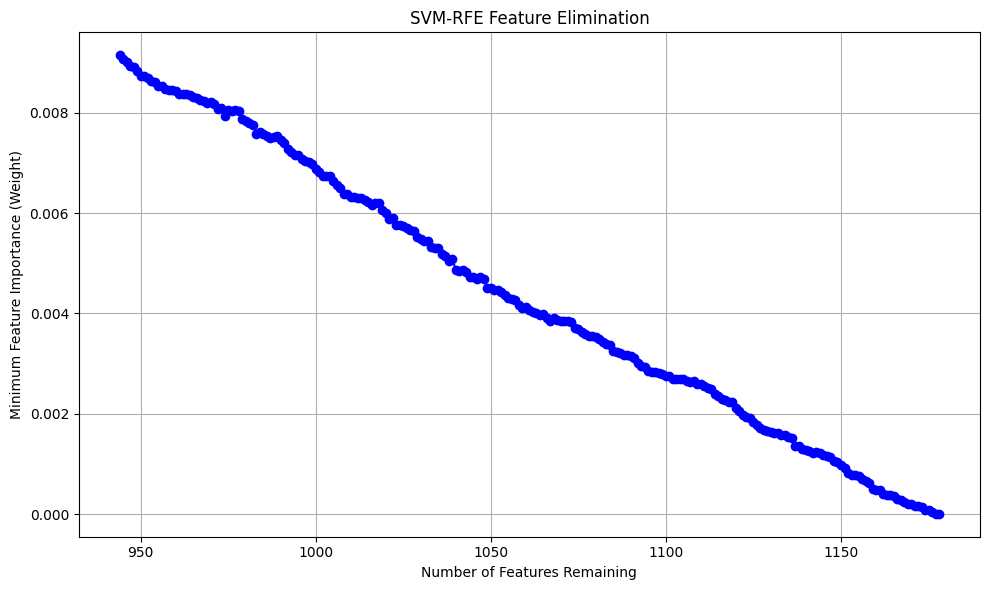

[OK] SVM-RFE plot saved to gse3360_svm_rfe_plot.png
[OK] SVM-RFE selected features saved to gse3360_svm_rfe_selected_features.csv
[DONE] Pipeline complete. Final output: gse3360_svm_rfe_selected_features.csv


In [18]:
# ============================================================
# CELL 9: SVM-RFE
# ============================================================
import math
import matplotlib.pyplot as plt
from sklearn.svm import SVC

print('='*60)
print('STEP 8: SVM-RFE FEATURE ELIMINATION')
print('='*60)

data = pd.read_csv(selected_features_file)
print(f'[INFO] Loaded {selected_features_file}: {data.shape}')

X = data.iloc[:, :-1].apply(pd.to_numeric)
y = data['CLASS'].astype('category').cat.codes
num_features_to_select = math.ceil((len(data.columns) - 1) * 0.8)
print(f'[INFO] Features in : {len(X.columns)}')
print(f'[INFO] Features out: {num_features_to_select}')

def svm_rfe_plot(X, y, num_keep):
    remaining = list(X.columns)
    ranking, n_remaining_track, min_weights_track = [], [], []
    iteration = 0
    while len(remaining) > num_keep:
        iteration += 1
        if iteration % 10 == 0:
            print(f'[DEBUG] SVM-RFE iteration {iteration}: {len(remaining)} features remaining')
        svc = SVC(kernel='linear', C=1.0)
        svc.fit(X[remaining], y)
        weights = np.abs(svc.coef_).flatten()
        if len(weights) != len(remaining):
            raise RuntimeError(
                f'[FATAL] SVM weight count ({len(weights)}) != feature count ({len(remaining)}).\n'
                '        This can happen with multiclass data and a linear SVM.'
            )
        least_idx = np.argmin(weights)
        ranking.append(remaining[least_idx])
        n_remaining_track.append(len(remaining) - 1)
        min_weights_track.append(weights[least_idx])
        remaining.pop(least_idx)
    ranking.extend(remaining)
    plt.figure(figsize=(10, 6))
    plt.plot(n_remaining_track, min_weights_track, marker='o', color='blue')
    plt.xlabel('Number of Features Remaining')
    plt.ylabel('Minimum Feature Importance (Weight)')
    plt.title('SVM-RFE Feature Elimination')
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'{folder_name}_svm_rfe_plot.png', dpi=150)
    plt.show()
    print(f'[OK] SVM-RFE plot saved to {folder_name}_svm_rfe_plot.png')
    return ranking[-num_keep:]

selected_feats = svm_rfe_plot(X, y, num_features_to_select)
out = data[selected_feats + ['CLASS']]
out.to_csv(svm_rfe_file, index=False)
print(f'[OK] SVM-RFE selected features saved to {svm_rfe_file}')
print(f'[DONE] Pipeline complete. Final output: {svm_rfe_file}')
